There is an undirected tree with n nodes labeled from 1 to n, rooted at node 1. The tree is represented by a 2D integer array edges of length n - 1, where edges[i] = [ui, vi] indicates that there is an edge between nodes ui and vi.

Initially, all edges have a weight of 0. You must assign each edge a weight of either 1 or 2.

The cost of a path between any two nodes u and v is the total weight of all edges in the path connecting them.

You are given a 2D integer array queries. For each queries[i] = [ui, vi], determine the number of ways to assign weights to edges in the path such that the cost of the path between ui and vi is odd.

Return an array answer, where answer[i] is the number of valid assignments for queries[i].

Since the answer may be large, apply modulo 109 + 7 to each answer[i].

Note: For each query, disregard all edges not in the path between node ui and vi.

 

Example 1:

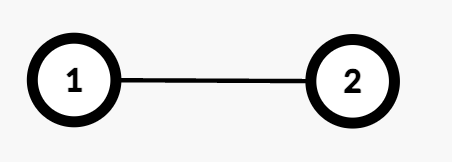

Input: edges = [[1,2]], queries = [[1,1],[1,2]]

Output: [0,1]

Explanation:

    Query [1,1]: The path from Node 1 to itself consists of no edges, so the cost is 0. Thus, the number of valid assignments is 0.
    Query [1,2]: The path from Node 1 to Node 2 consists of one edge (1 → 2). Assigning weight 1 makes the cost odd, while 2 makes it even. Thus, the number of valid assignments is 1.

Example 2:

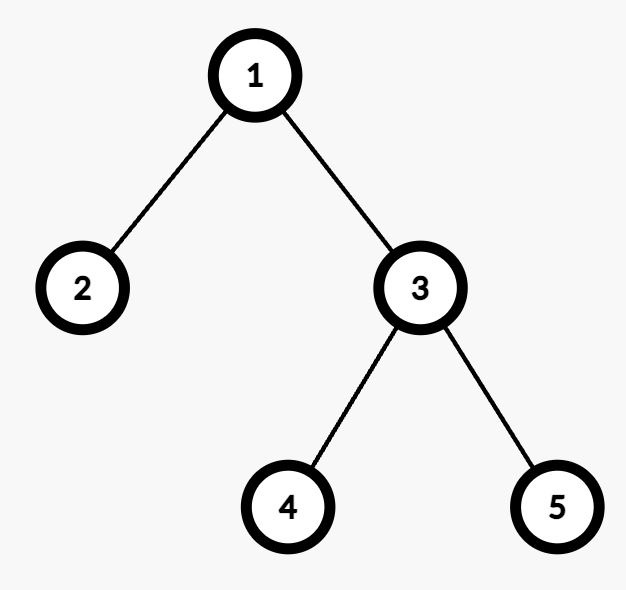

Input: edges = [[1,2],[1,3],[3,4],[3,5]], queries = [[1,4],[3,4],[2,5]]

Output: [2,1,4]

Explanation:

    Query [1,4]: The path from Node 1 to Node 4 consists of two edges (1 → 3 and 3 → 4). Assigning weights (1,2) or (2,1) results in an odd cost. Thus, the number of valid assignments is 2.
    Query [3,4]: The path from Node 3 to Node 4 consists of one edge (3 → 4). Assigning weight 1 makes the cost odd, while 2 makes it even. Thus, the number of valid assignments is 1.
    Query [2,5]: The path from Node 2 to Node 5 consists of three edges (2 → 1, 1 → 3, and 3 → 5). Assigning (1,2,2), (2,1,2), (2,2,1), or (1,1,1) makes the cost odd. Thus, the number of valid assignments is 4.

 

Constraints:

    2 <= n <= 105
    edges.length == n - 1
    edges[i] == [ui, vi]
    1 <= queries.length <= 105
    queries[i] == [ui, vi]
    1 <= ui, vi <= n
    edges represents a valid tree.


In [ ]:
class Solution:
    def assignEdgeWeights(self, edges: List[List[int]], queries: List[List[int]]) -> List[int]:
        lca = LCA(edges, 1)
        m = len(queries)
        res = [0] * m

        for i in range(m):
            x, y = queries[i][0], queries[i][1]
            if x != y:
                res[i] = p2[lca.dis(x, y) - 1]

        return res


import math
from typing import List


class LCA:
    def __init__(self, edges: List[List[int]], root: int = 1):
        self.n = len(edges) + 1
        self.m = int(math.log2(self.n)) + 2
        self.e = [[] for _ in range(self.n + 1)]
        self.d = [0] * (self.n + 1)
        self.f = [[0] * self.m for _ in range(self.n + 1)]

        for u, v in edges:
            self.e[u].append(v)
            self.e[v].append(u)

        self.dfs(root, 0)

        for i in range(1, self.m):
            for x in range(1, self.n + 1):
                self.f[x][i] = self.f[self.f[x][i - 1]][i - 1]

    def dfs(self, x: int, fa: int):
        self.f[x][0] = fa
        for y in self.e[x]:
            if y == fa:
                continue
            self.d[y] = self.d[x] + 1
            self.dfs(y, x)

    def lca(self, x: int, y: int) -> int:
        if self.d[x] > self.d[y]:
            x, y = y, x

        # raise y to the same depth as x
        diff = self.d[y] - self.d[x]
        for i in range(self.m - 1, -1, -1):
            if diff & (1 << i):
                y = self.f[y][i]

        if x == y:
            return x

        for i in range(self.m - 1, -1, -1):
            if self.f[x][i] != self.f[y][i]:
                x = self.f[x][i]
                y = self.f[y][i]

        return self.f[x][0]

    def dis(self, x: int, y: int) -> int:
        return self.d[x] + self.d[y] - self.d[self.lca(x, y)] * 2


MOD = 10**9 + 7
N = 100010
p2 = [0] * N


def init():
    p2[0] = 1
    for i in range(1, N):
        p2[i] = p2[i - 1] * 2 % MOD


init()
